# qiu_2026 — in-silico analyses (from saved results)

The same analyses and the same figures as `qiu_2026_insilico.ipynb`, read from the `.npz` files that
notebook writes. **No model, no checkpoint, no dataset, no GPU** — it runs on a laptop in seconds,
which is what makes the results explorable interactively.

Everything downstream of the loading cells is copied verbatim from the producer notebook, so the two
cannot drift in what they show. What is *not* here is the machinery that produced the numbers: the
MEI optimization, the behavior sweeps, and the validation pass. Read `qiu_2026_insilico.ipynb` for
those, and re-run it if you want to change how the results are computed.

**Prerequisite.** Run `qiu_2026_insilico.ipynb` once (see `run_qiu_insilico_notebook.sh` for the
Slurm submission) so that `openretina_assets/insilico/qiu_2026/<session>/` exists.

In [ ]:
%matplotlib inline

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

# ---- config: edit these ----
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SESSION = None    # None -> the only session present under the results root (errors if ambiguous)
VARIANT = None    # None -> the baseline run; or a variant name, e.g. "smooth1000"
# ----------------------------

RESULTS_ROOT = REPO / "openretina_assets/insilico/qiu_2026"
assert RESULTS_ROOT.exists(), (
    f"No saved results at {RESULTS_ROOT}.\nRun notebooks/qiu_2026_insilico.ipynb first "
    "(run_qiu_insilico_notebook.sh submits it to Slurm)."
)

available = sorted(p.name for p in RESULTS_ROOT.iterdir() if (p / "metadata.json").exists())
assert available, f"{RESULTS_ROOT} has no session directory containing metadata.json."
if SESSION is None:
    assert len(available) == 1, f"Several sessions saved; set SESSION to one of {available}"
    SESSION = available[0]
assert SESSION in available, f"{SESSION!r} not among {available}"

SESSION_DIR = RESULTS_ROOT / SESSION

# Variant runs -- the same notebook at different MEI settings -- live in subdirectories, so runs can
# be compared instead of overwriting each other. `None` means the baseline directly under the session.
variants = sorted(p.name for p in SESSION_DIR.iterdir() if p.is_dir() and (p / "metadata.json").exists())
if VARIANT is not None:
    assert VARIANT in variants, f"{VARIANT!r} not among {variants or 'no variants saved'}"
    RESULTS_DIR = SESSION_DIR / VARIANT
else:
    assert (SESSION_DIR / "metadata.json").exists(), (
        f"No baseline run in {SESSION_DIR}; set VARIANT to one of {variants}"
    )
    RESULTS_DIR = SESSION_DIR

print("reading:", RESULTS_DIR)
print("variant:", VARIANT or "<baseline>", "| also available:", variants or "none")

### What is on disk

The producer writes each artifact as it is computed. The cell below reads all of them and rebuilds
exactly the variables the analysis cells expect — `meis`, `grids`, `population_grids`, `shifts`,
`pupil_grid`, `top_boutons`, `val_corr`, `behavior_trace` — so every cell after this point is
identical to the one in the producer notebook.

```
metadata.json            run parameters: checkpoint, behavior states, MEI settings, constants
boutons.npz              val_corr (all boutons), top_boutons (the ones with MEIs)
meis.npz                 stimuli (n_boutons, n_states, T, H, W), the gradient-support masks,
                         the per-iteration objective traces, and the per-MEI diagnostics
mei_knob_sweep.npz       contrast / smoothness / window / seed ladders, and cross-seed correlations
grid_sampled_{MEI,grey}.npz      behavior sweep, sampled boutons, with gradients
grid_population_{MEI,grey}.npz   behavior sweep, all boutons, no gradients
grid_pupil_center.npz    eye-position sweep
shifter.npz              per-session shift fields, align_corners, core output shape
behavior_trace.npz       recorded behavior, for the empirical-density overlay
```

In [ ]:
from openretina.insilico import ResponseGrid, shift_to_core_pixels

metadata = json.loads((RESULTS_DIR / "metadata.json").read_text())

_meis_npz = np.load(RESULTS_DIR / "meis.npz")
_boutons_npz = np.load(RESULTS_DIR / "boutons.npz")
_shifter_npz = np.load(RESULTS_DIR / "shifter.npz")

# Settings the producer used. Reading them back rather than re-deriving them keeps this notebook
# honest: it describes the run that actually happened, not the defaults it would use today.
MEI_TIME_STEPS = int(metadata["mei_time_steps"])
BEHAVIOR_CHANNELS = tuple(metadata["behavior_channels"])
PUPIL_CENTER = tuple(metadata["pupil_center"])
BEHAVIOR_STATES = {name: tuple(value) for name, value in metadata["behavior_states"].items()}
min_max_values = [tuple(metadata["stimulus_range"])]
mei_norm_whole_frame = float(metadata["mei_norm_target_whole_frame"])
MEI_LEARNING_RATES = tuple(metadata["mei_learning_rates"])
MAX_ITERATIONS = int(metadata["mei_max_iterations"])
RESPONSE_WINDOW = int(metadata["mei_response_window"])
REFERENCE_STATE = metadata["behavior_reference_state"]
N_BOUTONS = int(metadata["n_top_boutons"])

val_corr = _boutons_npz["val_corr"]
top_boutons = _boutons_npz["top_boutons"].tolist()
behavior_trace = np.load(RESULTS_DIR / "behavior_trace.npz")["behavior_trace"]

# The producer's per-MEI diagnostics, saved alongside the stimuli.
METRIC_KEYS = ("support_px", "rms_inside", "clipped_frac", "norm_outside_frac", "autocorr_lag1", "rank1_frac")

# Rebuild the MEI dict in the producer's layout: (bouton, state) -> record, stimulus as (1, 1, T, H, W).
state_order = [str(s) for s in _meis_npz["state_names"]]
meis = {
    (bouton, state): {
        "stimulus": torch.from_numpy(_meis_npz["stimuli"][b_i, s_i])[None, None],
        "before": float(_meis_npz["response_before"][b_i, s_i]),
        "after": float(_meis_npz["response_after"][b_i, s_i]),
        "lr": float(_meis_npz["learning_rate"][b_i, s_i]),
        "support": torch.from_numpy(_meis_npz["support"][b_i, s_i]),
        "trace": _meis_npz["traces"][b_i, s_i],
        "norm_target": float(_meis_npz["norm_target"][b_i, s_i]),
        "trace_final": float(_meis_npz["response_trace_final"][b_i, s_i]),
        **{key: float(_meis_npz[key][b_i, s_i]) for key in METRIC_KEYS},
    }
    for b_i, bouton in enumerate(top_boutons)
    for s_i, state in enumerate(state_order)
}

grids = {n: ResponseGrid.load(RESULTS_DIR / f"grid_sampled_{n}.npz") for n in ("MEI", "grey")}
population_grids = {n: ResponseGrid.load(RESULTS_DIR / f"grid_population_{n}.npz") for n in ("MEI", "grey")}
pupil_grid = ResponseGrid.load(RESULTS_DIR / "grid_pupil_center.npz")

shifts = {str(s): shift for s, shift in zip(_shifter_npz["sessions"], _shifter_npz["shifts"])}
core_output_shape = tuple(_shifter_npz["core_output_shape"])
align_corners = {str(s): bool(a) for s, a in zip(_shifter_npz["sessions"], _shifter_npz["align_corners"])}
BEHAVIOR_SWEEP_RANGE = (float(_shifter_npz["pupil_values"][0]), float(_shifter_npz["pupil_values"][-1]))

reference_state = REFERENCE_STATE
probe_bouton = top_boutons[0]
mei_video = meis[(probe_bouton, reference_state)]["stimulus"][0, 0]

print("checkpoint :", Path(metadata["checkpoint"]).name)
print("settings   : rms_factor={} smoothness={} window={} iters={}".format(
    metadata["mei_rms_factor"], metadata["mei_smoothness"], RESPONSE_WINDOW, MAX_ITERATIONS))
print("session    :", metadata["session"], f'({metadata["n_boutons_session"]} boutons)')
print(f'validation correlation: mean={metadata["val_corr_mean"]:.3f} median={metadata["val_corr_median"]:.3f}')
print("MEIs       :", _meis_npz["stimuli"].shape, "(boutons, states, T, H, W)  states:", state_order)
print("grids      :", {k: v.responses.shape for k, v in grids.items()})
print("population :", {k: v.responses.shape for k, v in population_grids.items()})
print("shifter    :", _shifter_npz["shifts"].shape, "for", len(shifts), "sessions")
print("behavior   :", behavior_trace.shape)
print("traces     :", _meis_npz["traces"].shape, f"({MAX_ITERATIONS} iterations each)")
_sweep_path = RESULTS_DIR / "mei_knob_sweep.npz"
_sweep_npz = np.load(_sweep_path) if _sweep_path.exists() else None
if _sweep_npz is None:
    print("knob sweep : not present (producer skipped it)")
else:
    # Older sweeps saved only the aggregate metrics; newer ones keep the stimuli too.
    sweep_stimuli = {
        name: _sweep_npz[f"{name}_stimuli"]
        for name in ("contrast", "smoothness", "window", "seed")
        if f"{name}_stimuli" in _sweep_npz
    }
    sweep_support = {
        name: _sweep_npz[f"{name}_support"]
        for name in ("contrast", "smoothness", "window", "seed")
        if f"{name}_support" in _sweep_npz
    }
    shapes = {k: v.shape for k, v in sweep_stimuli.items()}
    print("knob sweep : loaded |", f"stimuli {shapes}" if shapes else "metrics only (no stimuli saved)")

## How these results were produced

Three decisions that everything below depends on.

**The behavior channels must not be optimized.** They are inputs, but they are not pixels — an
unconstrained MEI would happily "paint" locomotion. `FixedChannelStimulusModel` exposes the
3-channel model as a 1-channel (video-only) model and splices the constants back in on every
forward pass, so the optimizer only ever sees the video.

This is not merely tidier than freezing channels after each step. `ChangeNormJointlyClipRangeSeparately`
normalizes over *all* channels jointly, so renormalizing a 3-channel tensor and then restoring the
behavior constants shrinks the video by the same factor every iteration — it decays geometrically to
zero. `tests/insilico/stimulus_optimization/test_fixed_channel_model.py` pins that behavior down so
nobody rediscovers it by watching an MEI fade out.

**The range and norm are measured, not guessed.** `STIMULUS_RANGE_CONSTRAINTS` comes from the 0.1/99.9
percentiles of the z-scored video over all 10 sessions (2.3 × 10⁹ pixels). Note the asymmetry —
`[-1.29, +2.96]` — the raw movie's mean sits well below mid-grey, so clipping symmetrically would be
wrong. The norm is *derived* from the stimulus size rather than tabulated, because MEI length is a
free choice and a norm fixed for one length is silently wrong for another.

**Eye position is pinned at the session mean.** The pupil trace is z-scored per session, so
`(0, 0)` is that session's mean eye position. It has to be the *same* value for MEI optimization and
for the behavior sweep, or the MEI is optimized at one receptive-field location and probed at
another. Passing `pupil_center=None` instead would pin the readout at the bare `mu`, which equals
the mean position only if the shifter happens to map the mean pupil to zero — not something to
assume.

**On the derived constants.** `MEI_TIME_STEPS`, the measured stimulus range and the MEI norm above
are read from `metadata.json` rather than re-imported from
`openretina.data_io.qiu_2026.constants`. If the constants in the library change, this notebook keeps
describing the run that produced these files; re-run the producer to pick up new ones.

## Which boutons?

17,300 boutons is far too many to optimize. Rank by how well the model predicts each one on held-out
data and take the top `N_BOUTONS`: an MEI for a bouton the model cannot predict is an artifact of
the fit, not a statement about the cell.

In [3]:
# Ranked in the producer by held-out validation correlation; reloaded here.
print(f"validation correlation: mean={np.nanmean(val_corr):.3f} median={np.nanmedian(val_corr):.3f}")
print(f"top {N_BOUTONS} boutons:", [(int(i), round(float(val_corr[i]), 3)) for i in top_boutons])

validation correlation: mean=0.560 median=0.554
top 24 boutons: [(1902, 0.863), (2364, 0.861), (2683, 0.853), (843, 0.85), (1653, 0.837), (955, 0.834), (556, 0.833), (1131, 0.818), (2668, 0.817), (1941, 0.816), (2625, 0.816), (2585, 0.815), (2648, 0.814), (1681, 0.812), (1114, 0.811), (945, 0.811), (584, 0.809), (1343, 0.809), (1019, 0.809), (2698, 0.807), (591, 0.807), (795, 0.806), (333, 0.805), (1329, 0.804)]


## 1. MEIs per bouton, at two behavioral states

One MEI per bouton per state. If the behavior channels only apply a gain, the two MEIs for a bouton
should differ in *amplitude* but keep the same spatiotemporal structure — that is the prediction the
architecture makes, and it is worth checking rather than assuming.

The states are the two modes of the recorded joint behavior distribution, not round z-numbers: the
locomotion channel is one-sided with a floor at ≈ `-0.19`, so `(-1, -1)` is below anything the animal
can produce and `(0, 0)` occurs in 0.07% of frames.

In [4]:
# The producer's optimizer settings, for reference (the optimization itself is not re-run here).
from collections import Counter

print("behavior states :", {k: tuple(v) for k, v in BEHAVIOR_STATES.items()})
print("step-size ladder:", MEI_LEARNING_RATES, "| max iterations:", metadata["mei_max_iterations"])
print("step size actually used:", dict(Counter(record["lr"] for record in meis.values())))

for bouton in top_boutons:
    gains = [meis[(bouton, s)]["after"] for s in BEHAVIOR_STATES]
    rates = {meis[(bouton, s)]["lr"] for s in BEHAVIOR_STATES}
    print(
        f"bouton {bouton:5d} | responses across states: "
        + "  ".join(f"{g:9.2f}" for g in gains)
        + f"   lr={sorted(rates)}"
    )

behavior states : {'stationary': (-0.2234632670879364, -0.18857252597808838), 'running': (3.354198455810547, 3.729773998260498)}
step-size ladder: (1.0, 0.3, 0.1) | max iterations: 1000
step size actually used: {0.3: 34, 1.0: 7, 0.1: 7}
bouton  1902 | responses across states:   5452.05    6053.24   lr=[0.3]
bouton  2364 | responses across states:   5356.17    6980.90   lr=[0.3, 1.0]
bouton  2683 | responses across states:   5807.34    4727.58   lr=[0.3, 1.0]
bouton   843 | responses across states:   7663.25    7680.34   lr=[0.3]
bouton  1653 | responses across states:   3741.53    3805.05   lr=[1.0]
bouton   955 | responses across states:   4022.84    8505.55   lr=[0.3, 1.0]
bouton   556 | responses across states:   7675.89    8030.57   lr=[0.3]
bouton  1131 | responses across states:   5470.77    5536.36   lr=[0.3]
bouton  2668 | responses across states:   6223.83    6270.77   lr=[0.3]
bouton  1941 | responses across states:   7334.09    7021.39   lr=[0.3]
bouton  2625 | responses acr

In [5]:
# The producer's sanity assertions, re-run against the saved arrays. Everything that can be checked
# without the model is checked here too, so a corrupted or truncated file is caught at load time
# rather than showing up as a strange-looking plot.
lo, hi = min_max_values[0]
norms = []
for (bouton, state_name), record in meis.items():
    stimulus = record["stimulus"]
    trace = record["trace"]
    tail = max(1, len(trace) // 10)
    assert np.median(trace[-tail:]) >= 0.9 * trace.max(), f"{bouton} @ {state_name}: trace collapsed"
    assert record["after"] > trace[0], f"objective did not increase for {bouton} @ {state_name}"
    assert record["after"] == trace.max(), "the saved stimulus should be the trace's best iterate"
    assert stimulus.shape[:3] == (1, 1, MEI_TIME_STEPS), stimulus.shape
    assert lo - 1e-4 <= float(stimulus.min()) and float(stimulus.max()) <= hi + 1e-4, "MEI left the measured range"
    assert record["norm_outside_frac"] < 0.05, f"{bouton} @ {state_name}: norm mostly outside the support"
    norms.append(float(torch.linalg.vector_norm(stimulus)))

# Not checkable here: the producer also asserts the frozen behavior channels are bit-exactly
# constant, which needs `FixedChannelStimulusModel` and therefore the model. The saved MEIs are
# video-only, so there are no behavior channels left to check.
print(f"{len(meis)} MEIs loaded; each finished at its peak and stayed in range.")
targets = [record["norm_target"] for record in meis.values()]
print(f"final norms: {min(norms):.1f}-{max(norms):.1f}   target before clipping"
      f" {min(targets):.1f}-{max(targets):.1f}   (whole-frame norm would be {mei_norm_whole_frame:.1f})")

orbit = np.array([(r["after"] - r["trace_final"]) / r["after"] for r in meis.values()])
print(f"  {'orbit width':20s} min {orbit.min():.2%}  median {np.median(orbit):.2%}  max {orbit.max():.2%}")

for key in METRIC_KEYS:
    values = np.array([record[key] for record in meis.values()])
    print(f"  {key:20s} min {values.min():.3f}  median {np.median(values):.3f}  max {values.max():.3f}")

48 MEIs loaded; each finished at its peak and stayed in range.
final norms: 54.7-103.6   target before clipping 105.4-105.4   (whole-frame norm would be 253.0)
  orbit width          min 0.00%  median 4.10%  max 18.88%
  support_px           min 400.000  median 400.000  max 400.000
  rms_inside           min 0.517  median 0.820  max 0.978
  clipped_frac         min 0.032  median 0.073  max 0.095
  norm_outside_frac    min 0.000  median 0.000  max 0.000
  autocorr_lag1        min -0.306  median 0.113  max 0.346
  rank1_frac           min 0.168  median 0.248  max 0.476


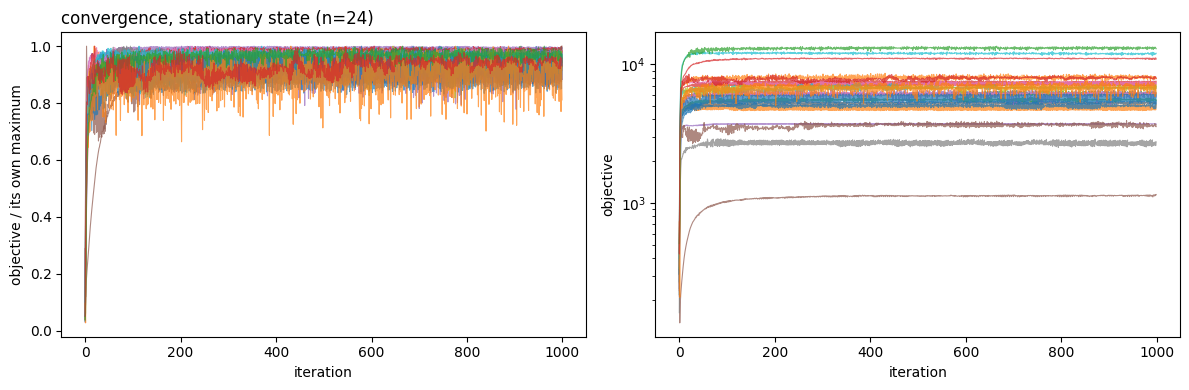

share of the total gain earned in the final 100 iterations:
  median -0.003%   max 8.477%


In [6]:
# Did the optimization converge? The producer's `TracedObjective` trace, saved per MEI.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for bouton in top_boutons:
    trace = meis[(bouton, REFERENCE_STATE)]["trace"]
    axes[0].plot(trace / trace.max(), lw=0.8, alpha=0.7)
    axes[1].plot(trace, lw=0.8, alpha=0.7)

axes[0].set_ylabel("objective / its own maximum")
axes[0].set_title(f"convergence, {REFERENCE_STATE} state (n={len(top_boutons)})", loc="left")
axes[1].set_yscale("log")
axes[1].set_ylabel("objective")
for ax in axes:
    ax.set_xlabel("iteration")
plt.tight_layout()
plt.show()

tail = max(1, MAX_ITERATIONS // 10)
tail_gain = np.array(
    [
        (record["trace"][-1] - record["trace"][-tail]) / (record["trace"][-1] - record["trace"][0])
        for record in meis.values()
    ]
)
print(f"share of the total gain earned in the final {tail} iterations:")
print(f"  median {np.median(tail_gain):.3%}   max {tail_gain.max():.3%}")

In [7]:
# The producer's knob sweep, reprinted from mei_knob_sweep.npz. Four one-factor-at-a-time ladders
# around the settings the main run used.
if _sweep_npz is None:
    print("No mei_knob_sweep.npz in this results directory; re-run the producer to generate it.")
else:
    def print_table(title: str, name: str) -> None:
        print(f"\n{title}")
        header = (
            f"  {'setting':>16} {'objective':>10} {'rms_in':>7} {'clip':>6}"
            f" {'outside':>8} {'r1':>6} {'rank1':>6}"
        )
        print(header)
        print("  " + "-" * (len(header) - 2))
        for row_index, label in enumerate(_sweep_npz[f"{name}_labels"]):
            print(
                f"  {str(label):>16} {_sweep_npz[f'{name}_objective'][row_index]:10.1f}"
                f" {_sweep_npz[f'{name}_rms_inside'][row_index]:7.2f}"
                f" {_sweep_npz[f'{name}_clipped_frac'][row_index]:6.1%}"
                f" {_sweep_npz[f'{name}_norm_outside_frac'][row_index]:8.1%}"
                f" {_sweep_npz[f'{name}_autocorr_lag1'][row_index]:+6.2f}"
                f" {_sweep_npz[f'{name}_rank1_frac'][row_index]:6.2f}"
            )

    print("swept boutons:", _sweep_npz["sweep_boutons"].tolist())
    print_table("Contrast ladder", "contrast")
    print_table("Spatial smoothness weight", "smoothness")
    print_table("Response window length (output frames)", "window")
    print_table("Seed stability", "seed")

    correlations = _sweep_npz["cross_seed_correlation"]
    print(
        f"\ncross-seed MEI correlation inside the support (n={len(correlations)} pairs): "
        f"median {np.median(correlations):+.3f}  min {correlations.min():+.3f}  max {correlations.max():+.3f}"
    )

swept boutons: [1902, 2364, 2683, 843]

Contrast ladder
           setting  objective  rms_in   clip  outside     r1  rank1
  -----------------------------------------------------------------
    rms_factor=0.1     2096.5    0.10   0.1%     0.0%  -0.32   0.57
   rms_factor=0.25     3413.6    0.22   0.5%     0.0%  -0.24   0.45
    rms_factor=0.5     5055.1    0.40   2.1%     0.0%  -0.25   0.39
    rms_factor=1.0     6457.6    0.80   7.9%     0.0%  -0.03   0.28

Spatial smoothness weight
           setting  objective  rms_in   clip  outside     r1  rank1
  -----------------------------------------------------------------
         spatial=0     6446.1    0.80   7.9%     0.0%  -0.03   0.28
       spatial=100     6121.9    0.75   6.2%     0.0%  +0.07   0.28
      spatial=1000     5386.7    0.85   4.0%     0.0%  +0.62   0.40
     spatial=10000     2223.3    0.99   1.8%     0.0%  -0.04   0.59

Response window length (output frames)
           setting  objective  rms_in   clip  outside     r1 

In [ ]:
# What the smoothness prior actually does to the MEI, from the saved sweep stimuli.
# Rows are boutons, columns are `factor_spatial` rungs, each cropped to that bouton's support and
# averaged over the last few frames of the response window.
if _sweep_npz is None or "smoothness" not in sweep_stimuli:
    print("No sweep stimuli in this results directory. Re-run the producer to generate them:")
    print("  ./run_qiu_insilico_variant.sh 1000 smooth1000")
else:
    labels = [str(x) for x in _sweep_npz["smoothness_labels"]]
    stimuli = sweep_stimuli["smoothness"]          # (n_settings, n_boutons, T, H, W)
    support = sweep_support["smoothness"]          # (n_settings, n_boutons, H, W)
    autocorr = _sweep_npz["smoothness_autocorr_lag1"]
    objective = _sweep_npz["smoothness_objective"]
    n_settings, n_boutons = stimuli.shape[:2]
    frames = 4                                     # average the last few frames for a stable map

    fig, axes = plt.subplots(
        n_boutons, n_settings, figsize=(2.1 * n_settings, 2.1 * n_boutons), squeeze=False
    )
    for bouton_index in range(n_boutons):
        for setting_index in range(n_settings):
            mask = support[setting_index, bouton_index]
            rows, cols = np.nonzero(mask)
            crop = stimuli[setting_index, bouton_index][
                -frames:, rows.min() : rows.max() + 1, cols.min() : cols.max() + 1
            ].mean(axis=0)
            limit = np.abs(crop).max() or 1.0
            ax = axes[bouton_index, setting_index]
            ax.imshow(crop, cmap="RdBu_r", vmin=-limit, vmax=limit)
            ax.set_xticks([])
            ax.set_yticks([])
            if bouton_index == 0:
                ax.set_title(
                    f"{labels[setting_index]}\nautocorr {autocorr[setting_index]:+.2f}", fontsize=8
                )
            if setting_index == 0:
                ax.set_ylabel(f"#{_sweep_npz['sweep_boutons'][bouton_index]}", fontsize=8)

    fig.suptitle(
        "Spatial smoothness prior — mean of the last "
        f"{frames} frames, cropped to each bouton's gradient support"
    )
    plt.tight_layout()
    plt.show()

    print(f"{'setting':>16} {'objective':>10} {'vs unregularized':>18} {'autocorr':>10}")
    for setting_index, label in enumerate(labels):
        share = objective[setting_index] / objective[0]
        print(f"  {label:>14} {objective[setting_index]:10.1f} {share:17.0%} {autocorr[setting_index]:+10.2f}")

**On the final norm.** `ChangeNormJointlyClipRangeSeparately` renormalizes *then* clips, so the clip
pulls the norm back below the target. That ordering is the postprocessor's existing semantics
(hoefling behaves the same way); the asymmetric measured range `[-1.29, +2.96]` just makes the effect
larger for qiu, because the negative side clips tightly.

What matters for interpretation is `norm_outside_frac` and `rms_inside`, not whether the total norm
hits an arbitrary target. The total is computed over the whole 36×64 frame, but a single bouton can
only be driven by ~20×20 of those pixels — so a norm that looks correct can still be describing mostly
unreachable pixels. `rms_inside` is the contrast the bouton actually sees, in the same units as the
`rms_video = 0.996` the target is built from — and the producer scales the norm target to the
support for exactly that reason, so `rms_inside` lands on `MEI_RMS_FACTOR * 0.996` by design
rather than 2.4x it.

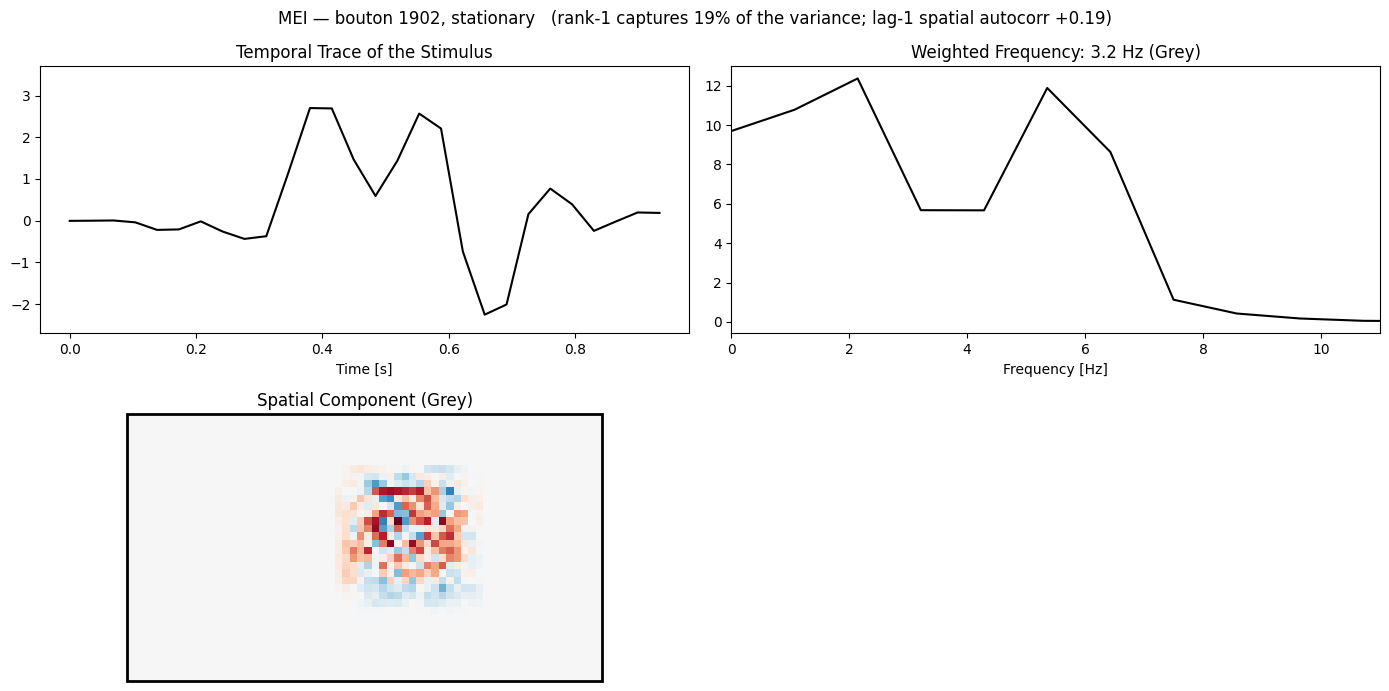

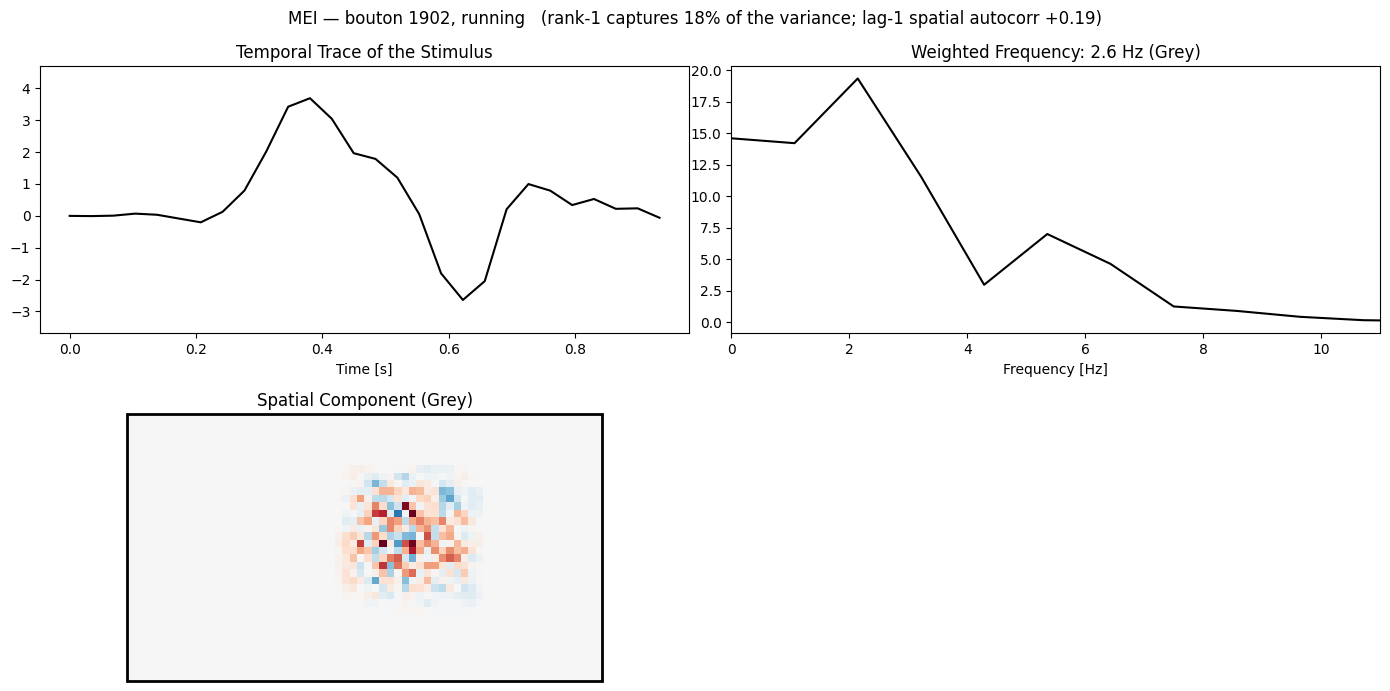

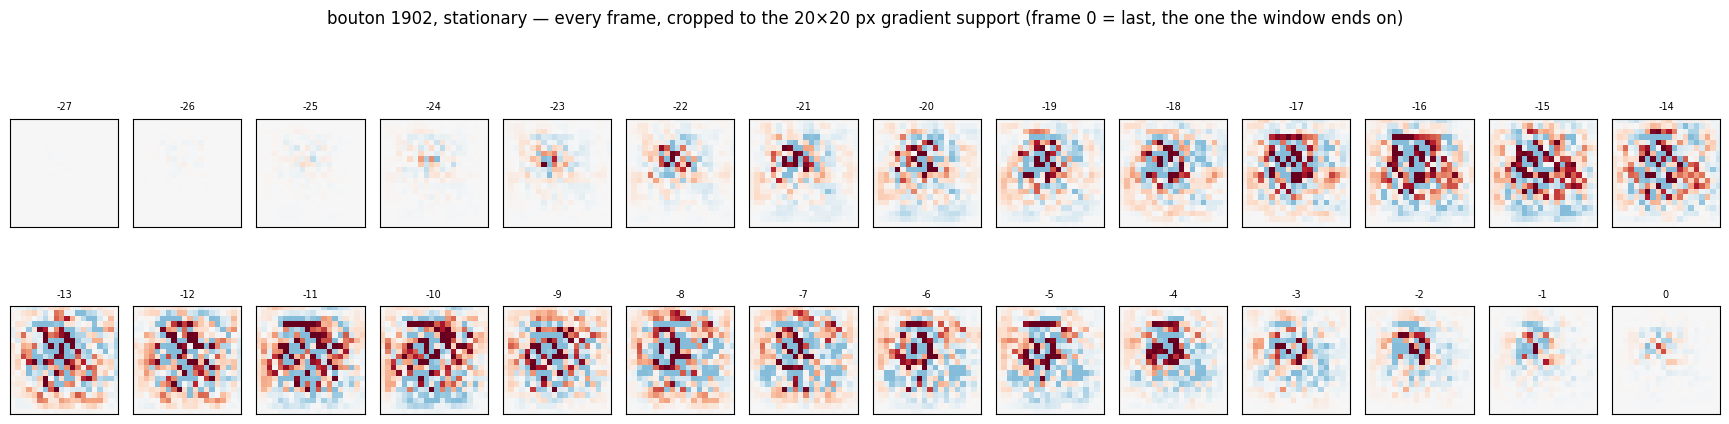

In [8]:
from openretina.utils.plotting import plot_stimulus_composition

# The optimized tensor is single-channel, so `plot_stimulus_composition` takes its greyscale path
# automatically. (Handing it 3 channels would run an SVD on the spatially-constant behavior channels,
# and at exactly 0.0 that divides by zero in video_analysis.py.) `scale_bar_label=None` because the
# bar's width is hard-coded for the hoefling retina geometry and means nothing here.
#
# The spatial panel is the *leading singular vector* of the whole tensor, so it is only a fair summary
# to the extent the MEI is space-time separable -- `rank1_frac` says how far that is true, printed
# next to each figure. Below it, the raw frames, which need no separability assumption at all.
bouton = top_boutons[0]
for state_name in BEHAVIOR_STATES:
    record = meis[(bouton, state_name)]
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    plot_stimulus_composition(
        stimulus=record["stimulus"][0],
        temporal_trace_ax=axes[0, 0],
        freq_ax=axes[0, 1],
        spatial_ax=axes[1, 0],
        scale_bar_label=None,
    )
    axes[1, 1].axis("off")
    fig.suptitle(
        f"MEI — bouton {bouton}, {state_name}   "
        f"(rank-1 captures {record['rank1_frac']:.0%} of the variance; "
        f"lag-1 spatial autocorr {record['autocorr_lag1']:+.2f})"
    )
    plt.tight_layout()
    plt.show()

# Every frame, cropped to the bouton's gradient support. No rank-1 assumption, and the crop is where
# the MEI actually lives.
record = meis[(bouton, REFERENCE_STATE)]
frames = record["stimulus"][0, 0].numpy()
rows, cols = np.nonzero(record["support"].numpy())
crop = frames[:, rows.min() : rows.max() + 1, cols.min() : cols.max() + 1]
limit = np.abs(crop).max()

fig, axes = plt.subplots(2, (MEI_TIME_STEPS + 1) // 2, figsize=(1.1 * MEI_TIME_STEPS / 2 + 2, 5))
for frame_index, ax in enumerate(axes.ravel()):
    if frame_index >= MEI_TIME_STEPS:
        ax.axis("off")
        continue
    ax.imshow(crop[frame_index], cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"{frame_index - MEI_TIME_STEPS + 1}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    f"bouton {bouton}, {REFERENCE_STATE} — every frame, cropped to the {crop.shape[1]}×{crop.shape[2]} px"
    f" gradient support (frame 0 = last, the one the window ends on)"
)
plt.tight_layout()
plt.show()

### plot a number of MEI spatial components

In [9]:
for state_name in BEHAVIOR_STATES:
    print(state_name)

stationary
running


/tmp/ipykernel_3242683/899335461.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(7, 3.5))


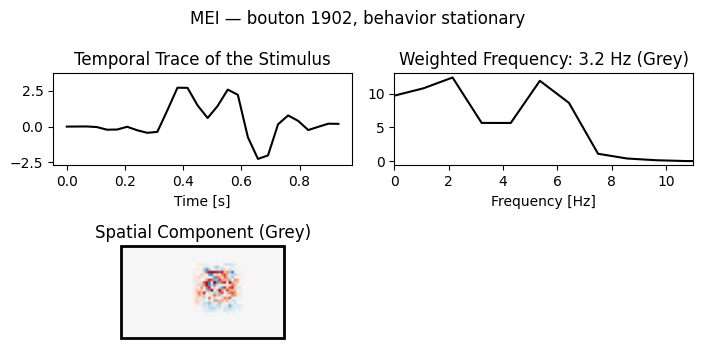

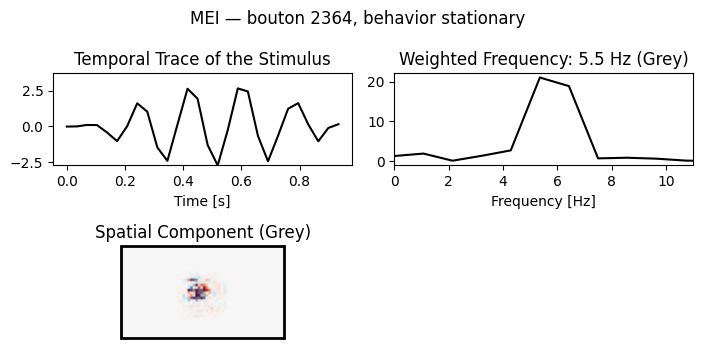

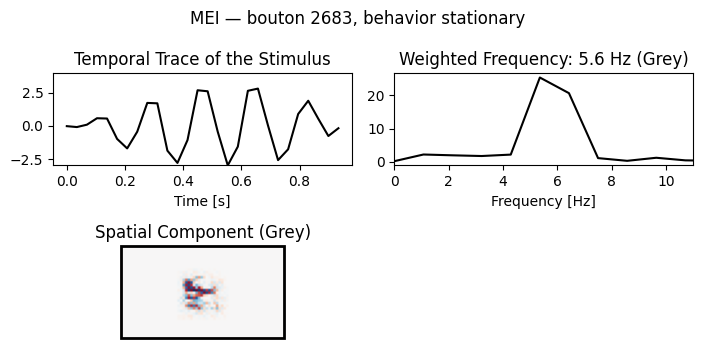

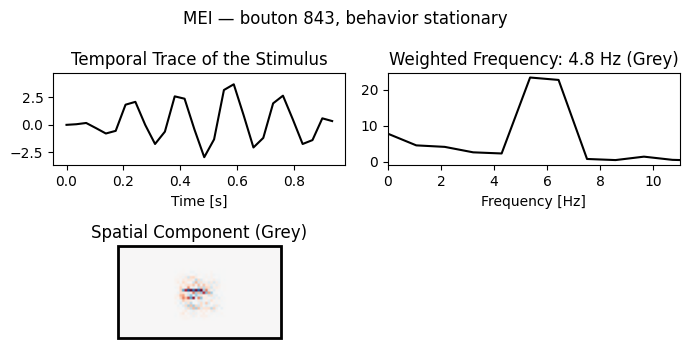

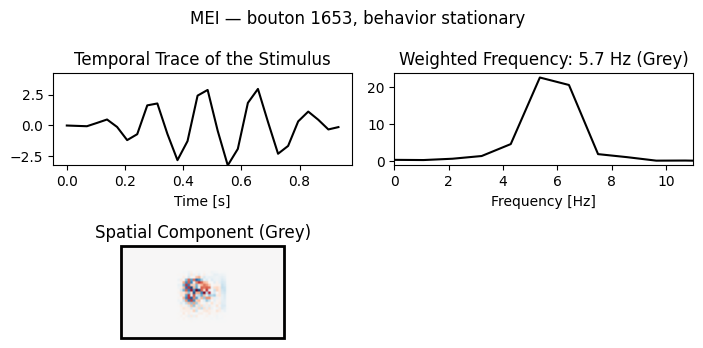

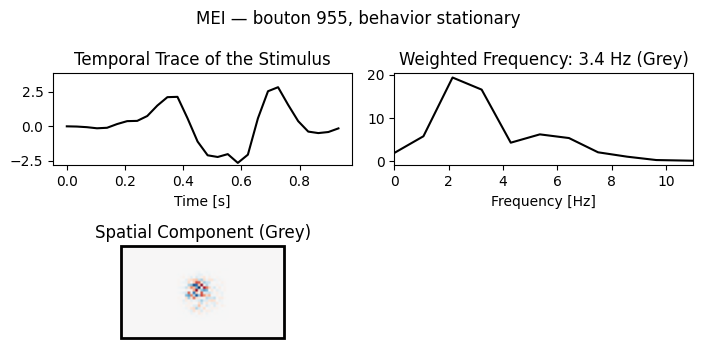

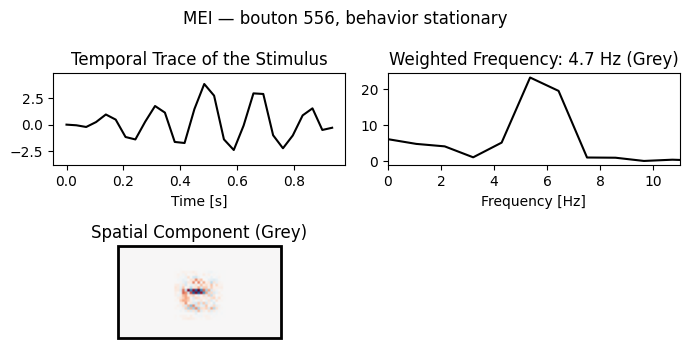

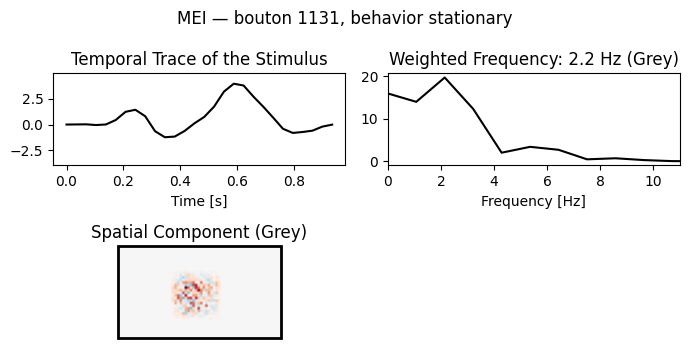

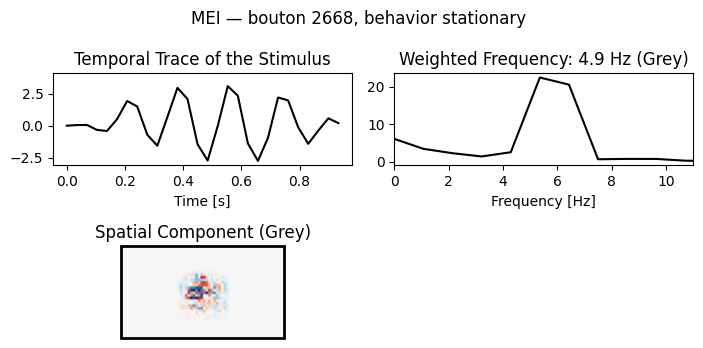

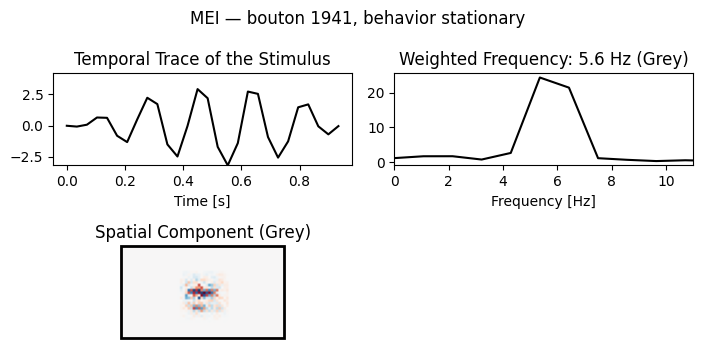

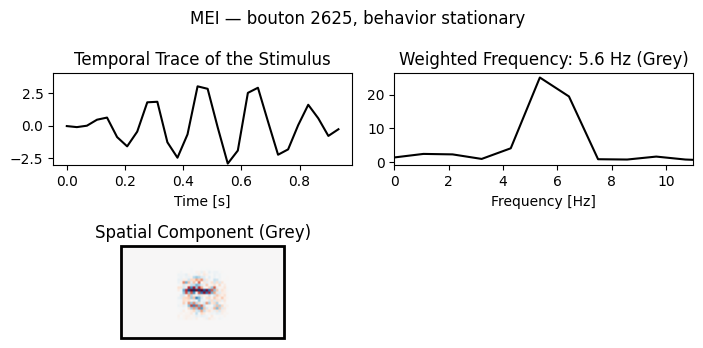

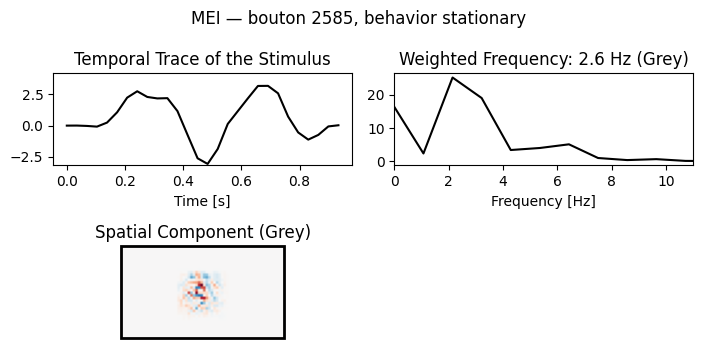

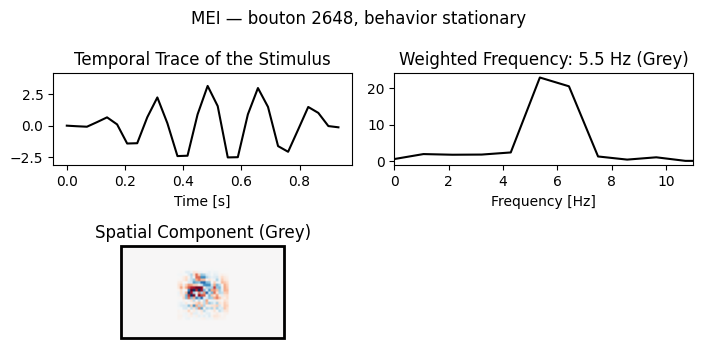

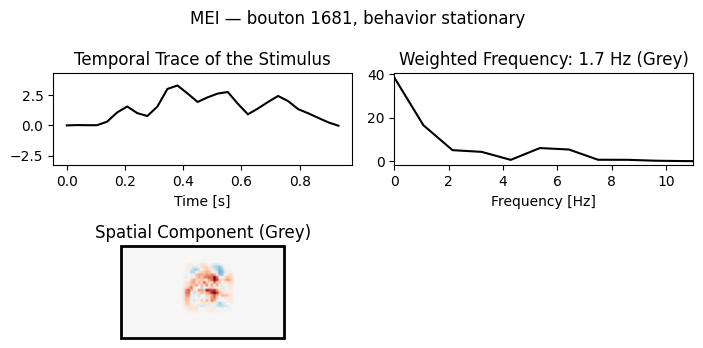

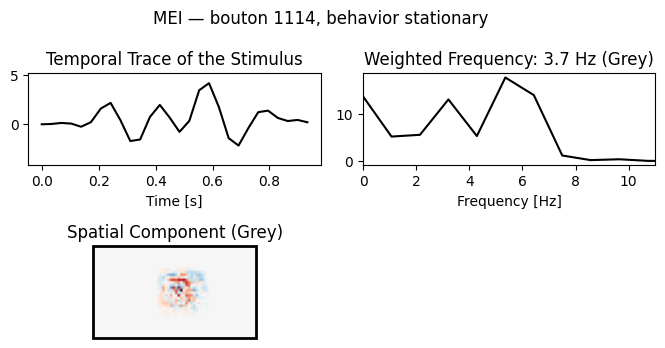

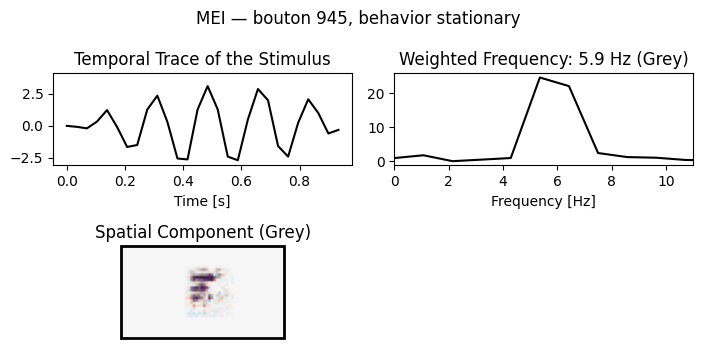

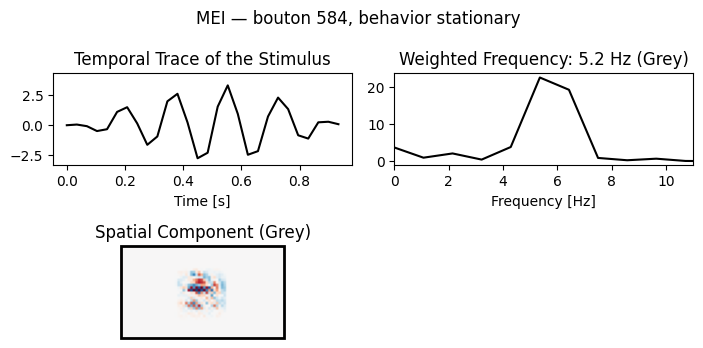

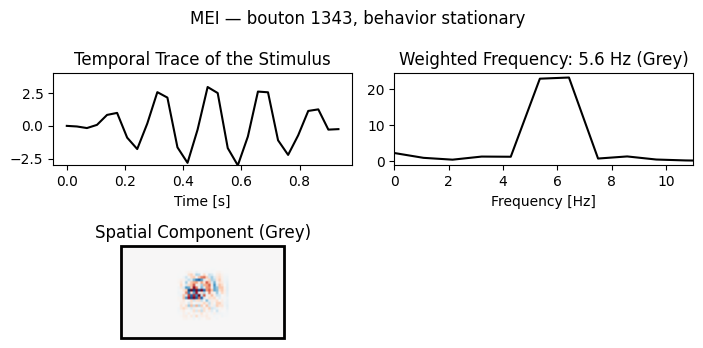

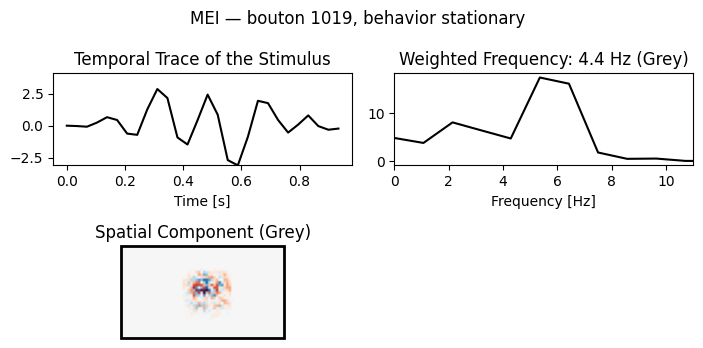

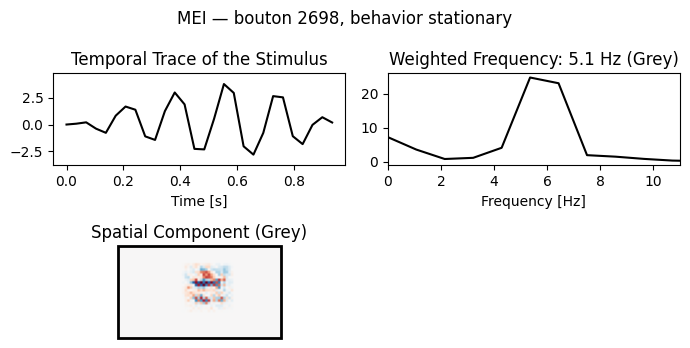

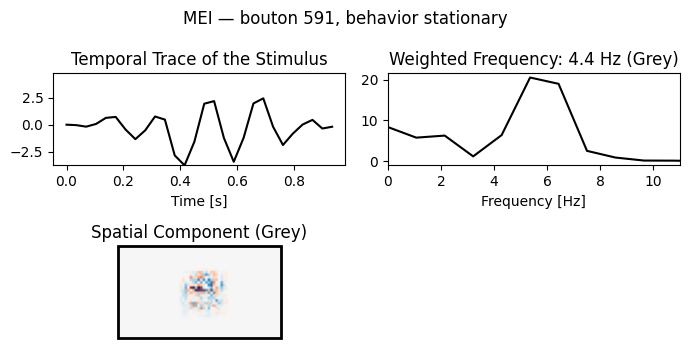

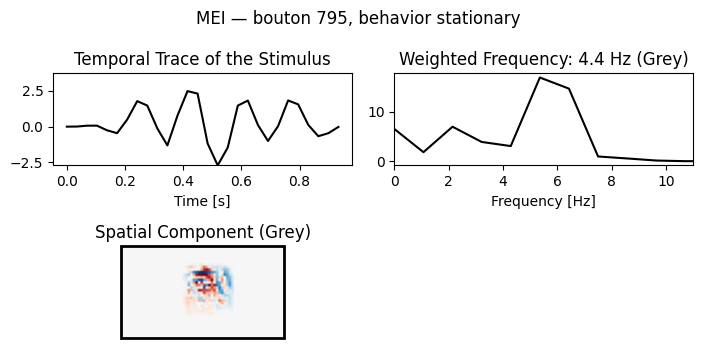

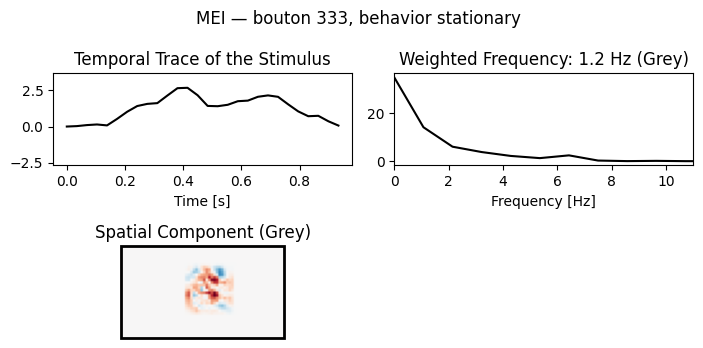

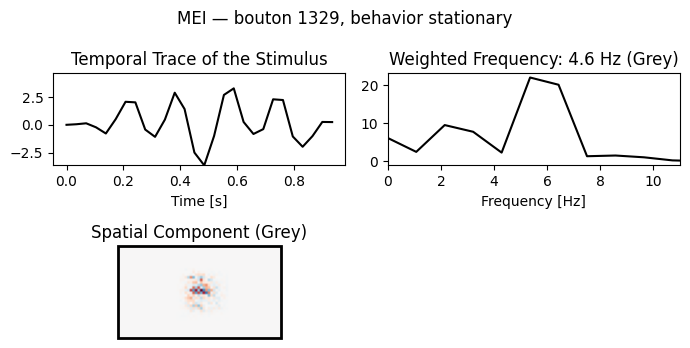

In [10]:
# The optimized tensor is single-channel, so `plot_stimulus_composition` takes its greyscale path
# automatically. (Handing it 3 channels would run an SVD on the spatially-constant behavior
# channels, and at exactly 0.0 that divides by zero in video_analysis.py.)
state_name = REFERENCE_STATE
for bouton in top_boutons:
    fig, axes = plt.subplots(2, 2, figsize=(7, 3.5))
    plot_stimulus_composition(
        stimulus=meis[(bouton, state_name)]["stimulus"][0],
        temporal_trace_ax=axes[0, 0],
        freq_ax=axes[0, 1],
        spatial_ax=axes[1, 0],
        scale_bar_label=None,
    )
    axes[1, 1].axis("off")
    fig.suptitle(f"MEI — bouton {bouton}, behavior {state_name}")
    plt.tight_layout()
plt.show()

/tmp/ipykernel_3242683/35147515.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(7, 3.5))


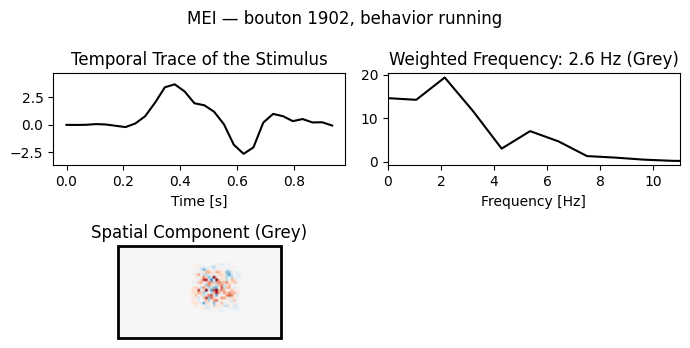

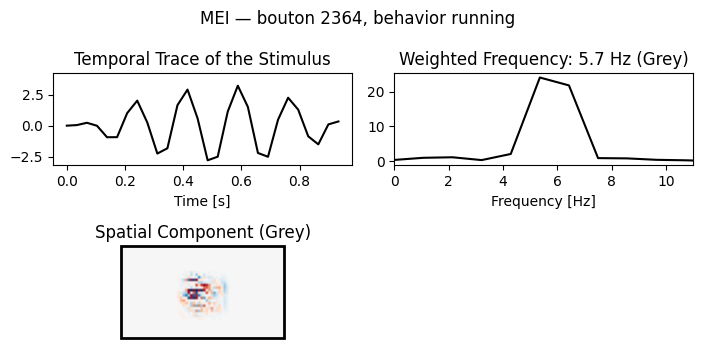

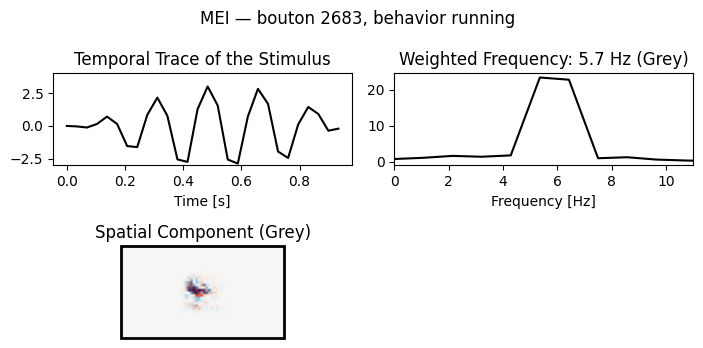

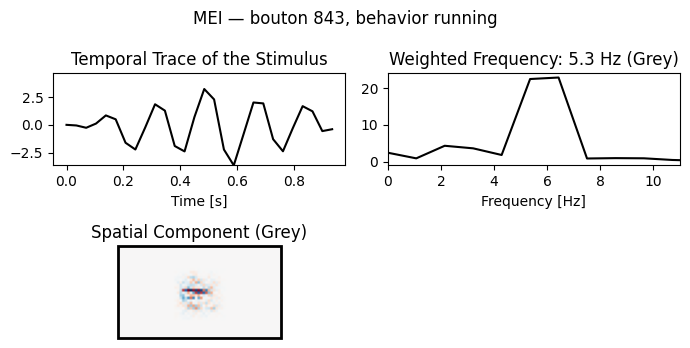

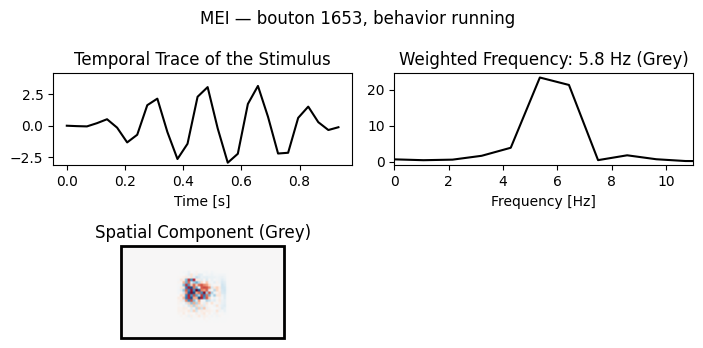

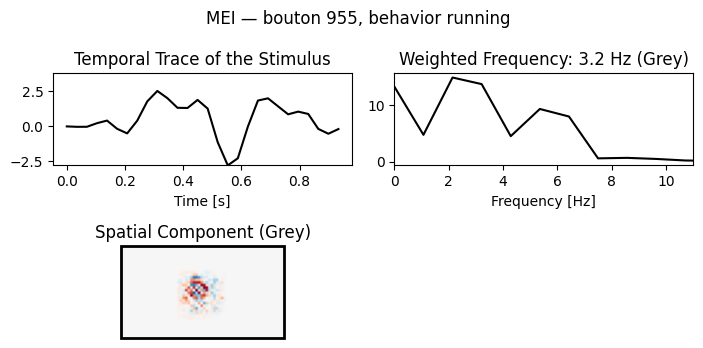

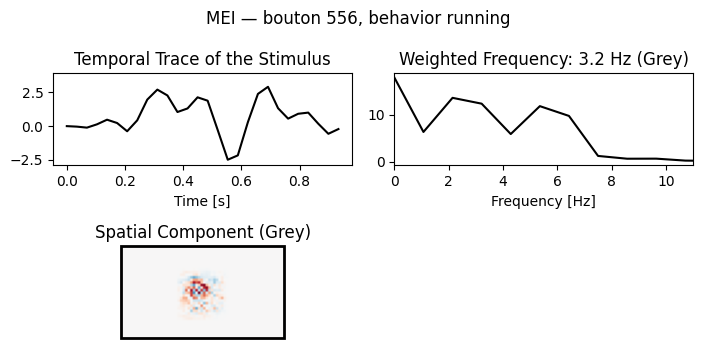

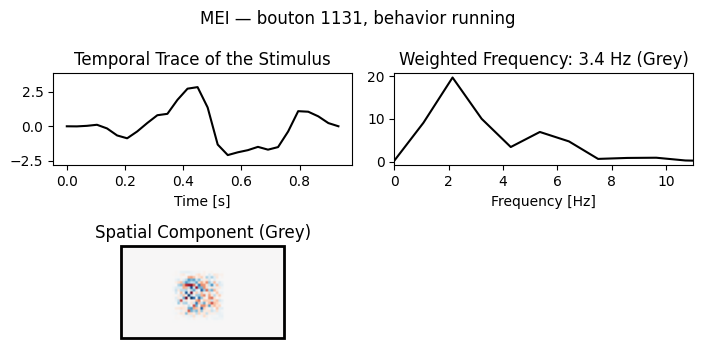

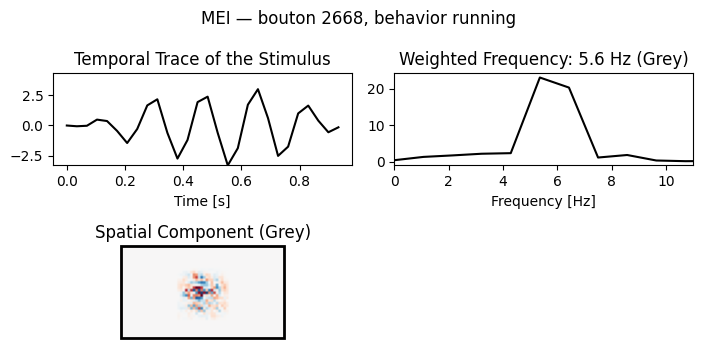

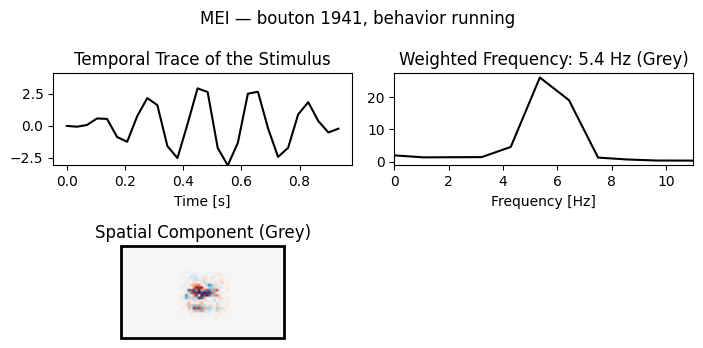

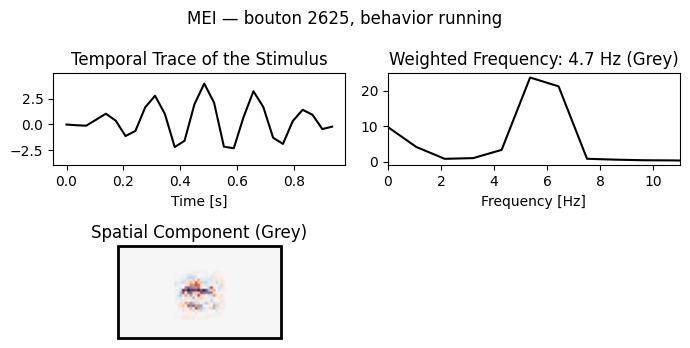

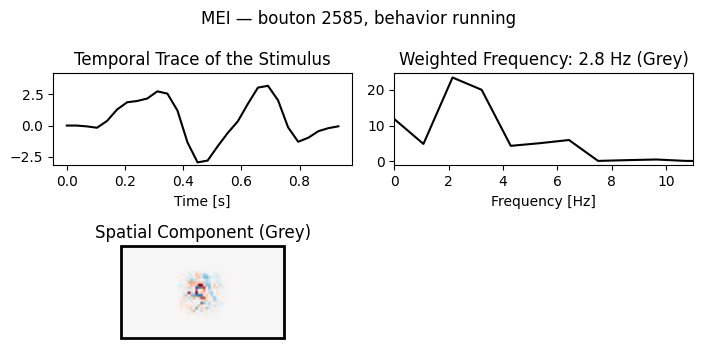

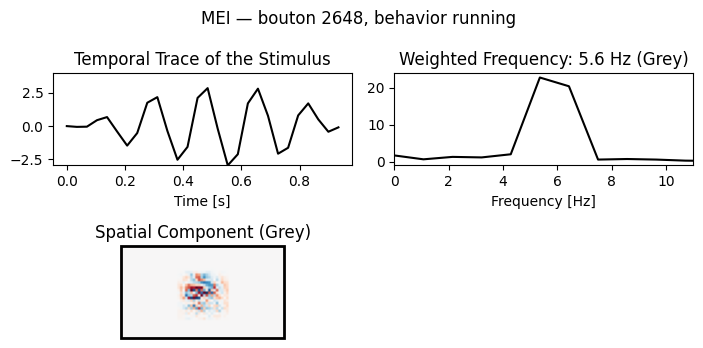

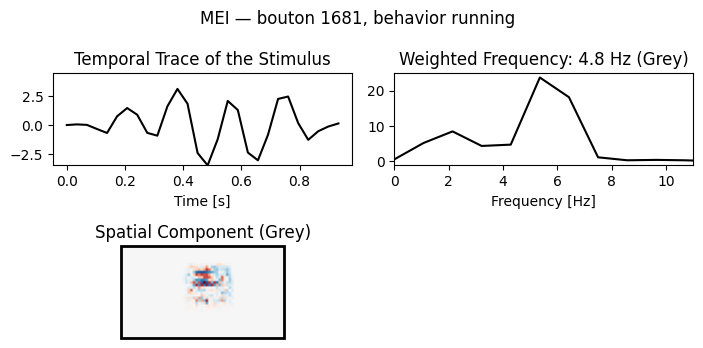

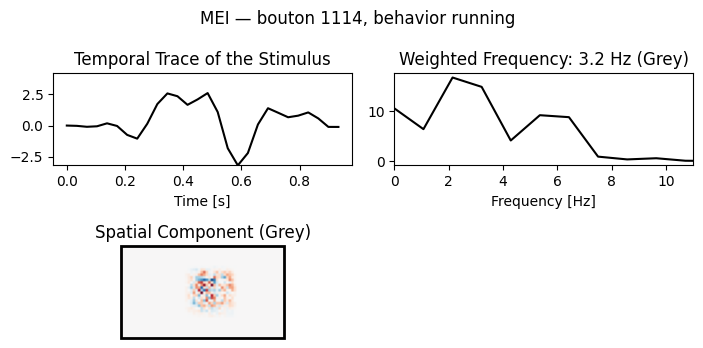

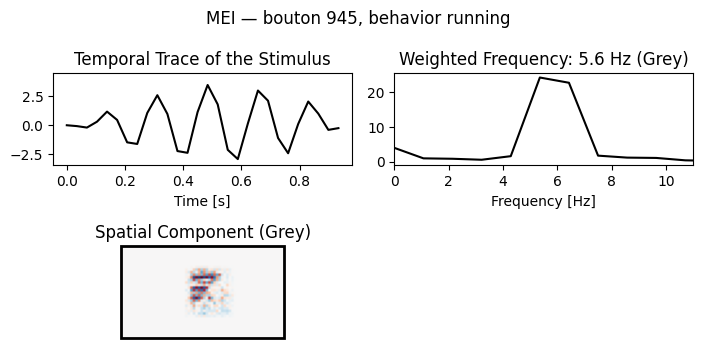

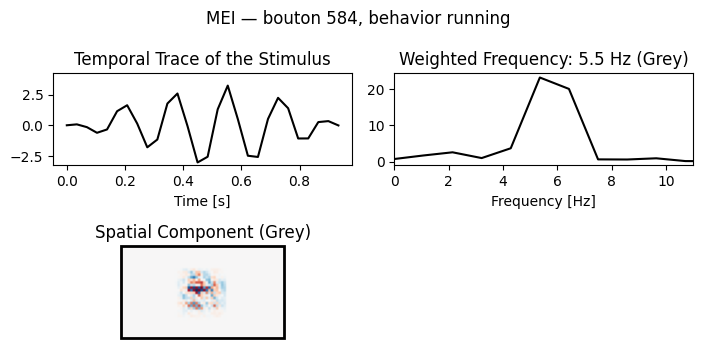

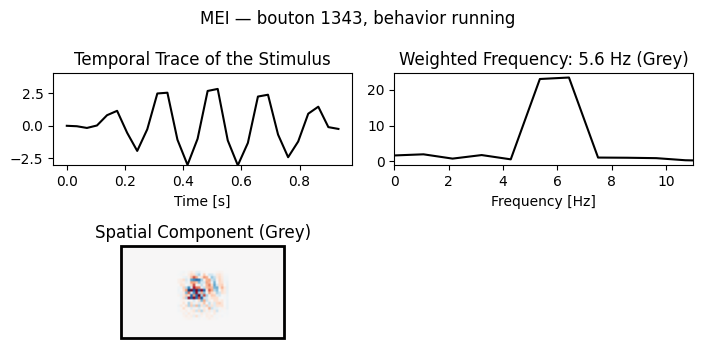

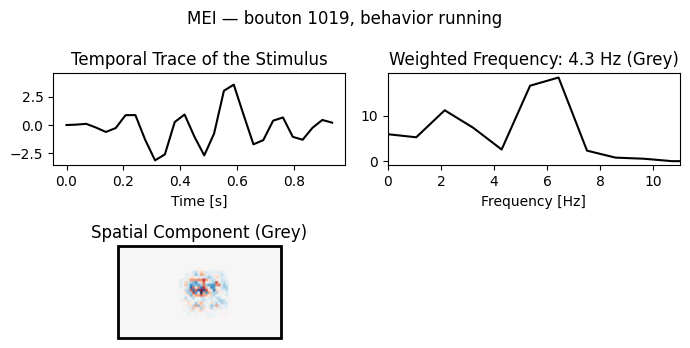

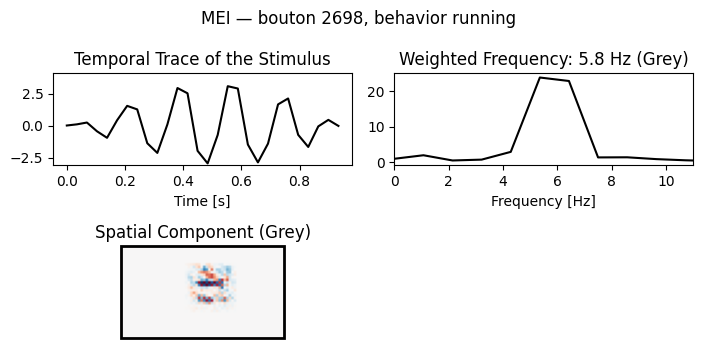

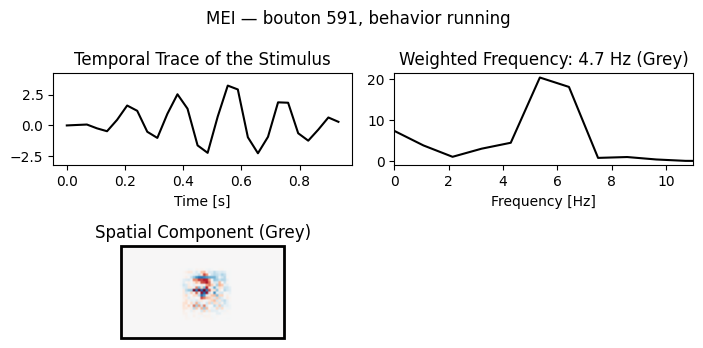

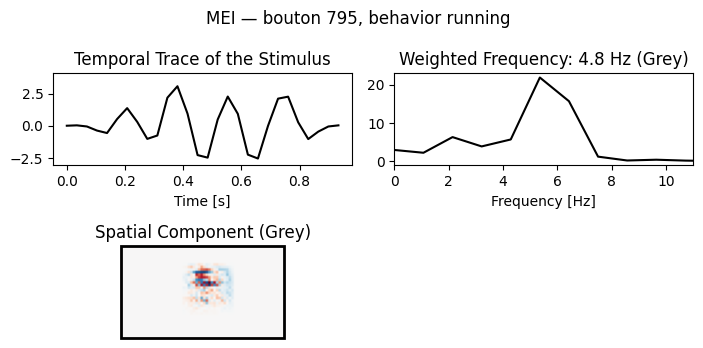

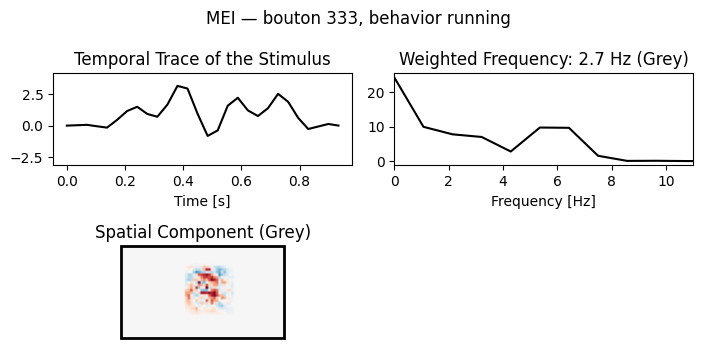

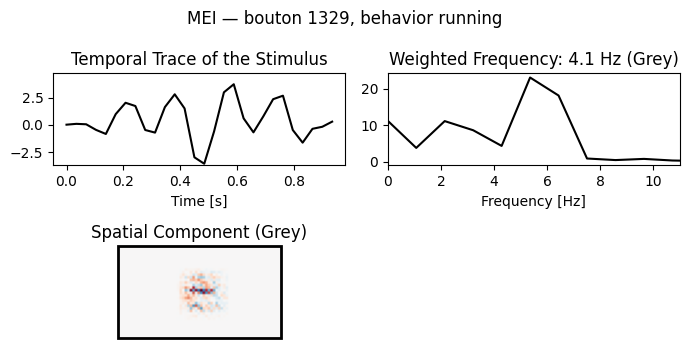

In [19]:
# The optimized tensor is single-channel, so `plot_stimulus_composition` takes its greyscale path
# automatically. (Handing it 3 channels would run an SVD on the spatially-constant behavior
# channels, and at exactly 0.0 that divides by zero in video_analysis.py.)
state_name = "running"
for bouton in top_boutons:
    fig, axes = plt.subplots(2, 2, figsize=(7, 3.5))
    plot_stimulus_composition(
        stimulus=meis[(bouton, state_name)]["stimulus"][0],
        temporal_trace_ax=axes[0, 0],
        freq_ax=axes[0, 1],
        spatial_ax=axes[1, 0],
        scale_bar_label=None,
    )
    axes[1, 1].axis("off")
    fig.suptitle(f"MEI — bouton {bouton}, behavior {state_name}")
    plt.tight_layout()
plt.show()

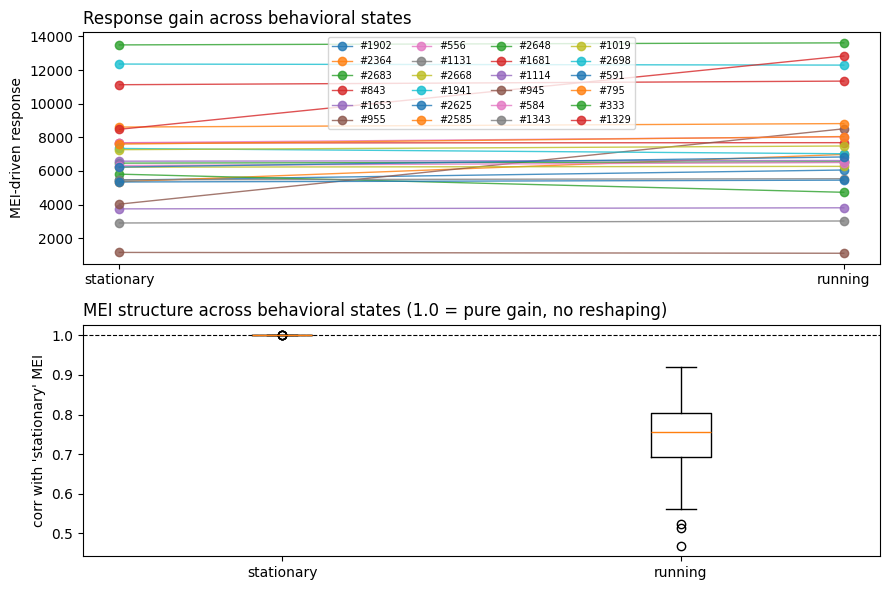

median similarity per state: {'stationary': np.float64(1.0), 'running': np.float64(0.756)}


In [11]:
# Does the behavior state rescale the MEI, or reshape it?
fig, axes = plt.subplots(2, 1, figsize=(9, 6))
state_names = list(BEHAVIOR_STATES)

for bouton in top_boutons:
    responses = np.array([meis[(bouton, s)]["after"] for s in state_names])
    axes[0].plot(range(len(state_names)), responses, marker="o", lw=1, alpha=0.8, label=f"#{bouton}")

axes[0].set_xticks(range(len(state_names)), state_names)
axes[0].set_ylabel("MEI-driven response")
axes[0].set_title("Response gain across behavioral states", loc="left")
axes[0].legend(fontsize=7, ncol=4)

# Spatial correlation between each state's MEI and the mean-state MEI, per bouton.
reference_state = REFERENCE_STATE
similarity = np.array(
    [
        [
            float(
                torch.corrcoef(
                    torch.stack(
                        [
                            meis[(bouton, s)]["stimulus"].flatten(),
                            meis[(bouton, reference_state)]["stimulus"].flatten(),
                        ]
                    )
                )[0, 1]
            )
            for s in state_names
        ]
        for bouton in top_boutons
    ]
)
axes[1].boxplot([similarity[:, i] for i in range(len(state_names))], tick_labels=state_names)
axes[1].axhline(1.0, color="k", ls="--", lw=0.8)
axes[1].set_ylabel(f"corr with '{reference_state}' MEI")
axes[1].set_title("MEI structure across behavioral states (1.0 = pure gain, no reshaping)", loc="left")
plt.tight_layout()
plt.show()

print("median similarity per state:", dict(zip(state_names, np.median(similarity, axis=0).round(3))))

## 2. Behavior-state modulation

`behavior_response_grid` holds one video fixed and sweeps the two behavior channels over a
17 × 17 grid spanning ±2 standard deviations, reducing each response over time.

Two probes, because the answer can depend on the stimulus: a bouton's own MEI (a strongly driving
input) and mid-grey (no drive at all, isolating the pure behavioral bias).

In [12]:
# Loaded above from grid_sampled_{MEI,grey}.npz -- the producer swept these on the GPU.
for probe_name, grid in grids.items():
    print(f"{probe_name:5s}: responses {grid.responses.shape}  axes {grid.axis_names}")

MEI  : responses (17, 17, 24)  axes ('pupil size [z]', 'locomotion [z]')
grey : responses (17, 17, 24)  axes ('pupil size [z]', 'locomotion [z]')


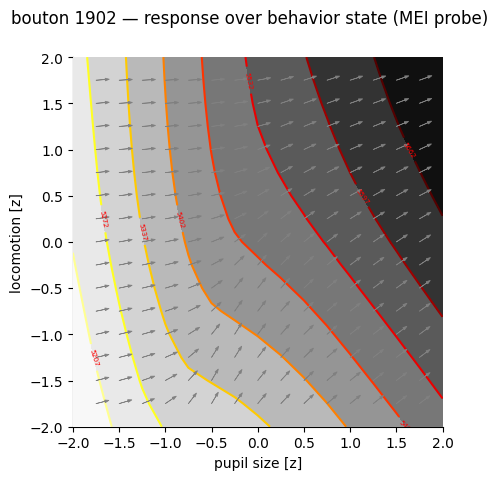

In [13]:
from openretina.utils.plotting import plot_vector_field_resp_iso

# `for_neuron` returns exactly the layout this plot expects. `tick_locations=None` matters: the
# default FixedLocator([-1, 0, 1]) is calibrated for the chromatic-contrast grid and would put all
# three ticks near the middle of a -2..+2 sweep.
grid = grids["MEI"]
neuron_slot = 0  # index into `top_boutons`
responses, gradients = grid.for_neuron(neuron_slot)

figure = plot_vector_field_resp_iso(
    grid.axis_values[0],
    grid.axis_values[1],
    gradients,
    responses,
    xlabel=grid.axis_names[0],
    ylabel=grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[neuron_slot]} — response over behavior state (MEI probe)")
plt.show()

### The grid visits states the animal never produced

A rectangular sweep necessarily includes combinations like pupil `+2` with locomotion `−2`. The
empirical joint density says which parts of the grid are actually supported; read the corners with
that in mind.

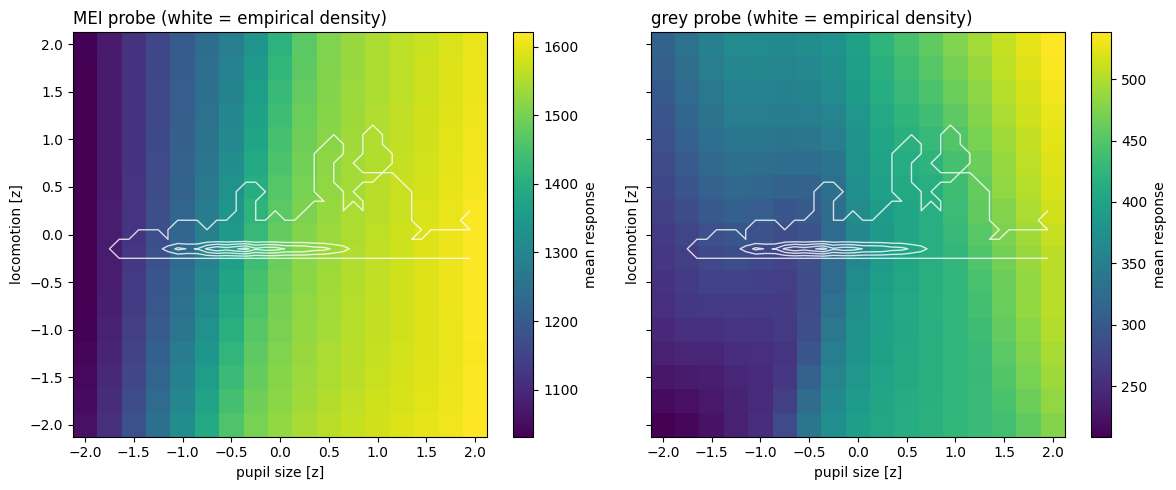

93.4% of recorded frames fall inside the swept +/-2 z range


In [14]:
# Empirical joint density of the two behavior channels, from the saved `behavior_trace.npz`.
# The producer captures it before its dataloader build releases the movies.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
edges = np.linspace(-2, 2, 41)

for ax, (probe_name, grid) in zip(axes, grids.items()):
    mean_response = grid.responses.mean(axis=-1)  # averaged over the sampled boutons
    mesh = ax.pcolormesh(
        grid.axis_values[0], grid.axis_values[1], mean_response.T, shading="nearest", cmap="viridis"
    )
    ax.contour(
        *np.meshgrid(0.5 * (edges[:-1] + edges[1:]), 0.5 * (edges[:-1] + edges[1:]), indexing="ij"),
        np.histogram2d(behavior_trace[0], behavior_trace[1], bins=[edges, edges])[0],
        levels=4,
        colors="white",
        linewidths=1.0,
        alpha=0.8,
    )
    fig.colorbar(mesh, ax=ax, label="mean response")
    ax.set_xlabel(grid.axis_names[0])
    ax.set_ylabel(grid.axis_names[1])
    ax.set_title(f"{probe_name} probe (white = empirical density)", loc="left")

plt.tight_layout()
plt.show()

in_range = ((np.abs(behavior_trace) <= 2).all(axis=0)).mean()
print(f"{in_range:.1%} of recorded frames fall inside the swept +/-2 z range")

MEI  : 2710/2710 finite | median 0.301
grey : 2710/2710 finite | median 0.280


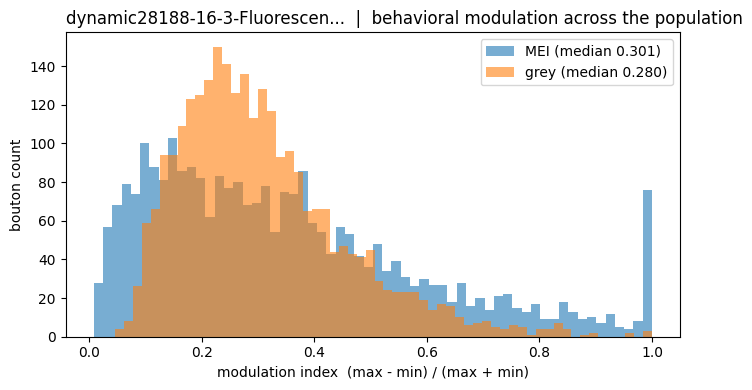

In [15]:
# Population modulation index over ALL boutons of this session, on both probes.
plt.figure(figsize=(7, 4))
for probe_name, grid in population_grids.items():
    index = grid.modulation_index()
    finite = index[np.isfinite(index)]
    plt.hist(finite, bins=60, alpha=0.6, label=f"{probe_name} (median {np.median(finite):.3f})")
    print(f"{probe_name:5s}: {len(finite)}/{len(index)} finite | median {np.median(finite):.3f}")

plt.xlabel("modulation index  (max - min) / (max + min)")
plt.ylabel("bouton count")
plt.title(f"{SESSION[:28]}...  |  behavioral modulation across the population", loc="left")
plt.legend()
plt.tight_layout()
plt.show()

## 3. The pupil shifter: how far does it move a receptive field?

`shifter_shift_grid` evaluates the shifter MLPs directly — no core, no readout, milliseconds for all
10 sessions. That answers the displacement question without the confound of a response.

The shift is in normalized grid units; `shift_to_core_pixels` converts to core-output pixels. Note
the last-axis order is `(width, height)`, because `grid_sample` reads `grid[..., 0]` as x.

In [16]:
# Shift fields loaded from shifter.npz, converted to core pixels exactly as the producer does.
print("core output (h, w):", core_output_shape)

rows = []
for session, shift in shifts.items():
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=align_corners[session])
    displacement = np.linalg.norm(pixels, axis=-1)
    rows.append((session, displacement.max(), np.abs(pixels[..., 0]).max(), np.abs(pixels[..., 1]).max()))

print(f"\n{'session':<44}{'max |shift|':>12}{'max dx':>9}{'max dy':>9}   (core pixels)")
for session, total, dx, dy in rows:
    print(f"{session[:42]:<44}{total:>12.2f}{dx:>9.2f}{dy:>9.2f}")

core output (h, w): (np.int64(18), np.int64(46))

session                                      max |shift|   max dx   max dy   (core pixels)
dynamic28188-16-3-Fluorescence-7b721b-v4a           2.99     2.91     1.44
dynamic28188-16-5-Fluorescence-7b721b-v4a           3.05     3.04     1.34
dynamic28188-17-2-Fluorescence-7b721b-v4a           4.53     3.98     3.25
dynamic28188-18-4-Fluorescence-7b721b-v4a           5.10     2.62     4.44
dynamic28188-19-9-Fluorescence-7b721b-v4a           2.46     2.45     1.77
dynamic28712-3-8-Fluorescence-7b721b-v4a            7.55     5.38     6.52
dynamic29163-2-7-Fluorescence-7b721b-v4a            5.23     4.98     1.59
dynamic29163-4-4-Fluorescence-7b721b-v4a            3.25     3.22     0.44
dynamic29163-5-8-Fluorescence-7b721b-v4a            2.29     2.26     0.35
dynamic29163-6-5-Fluorescence-7b721b-v4a            2.53     2.11     2.10


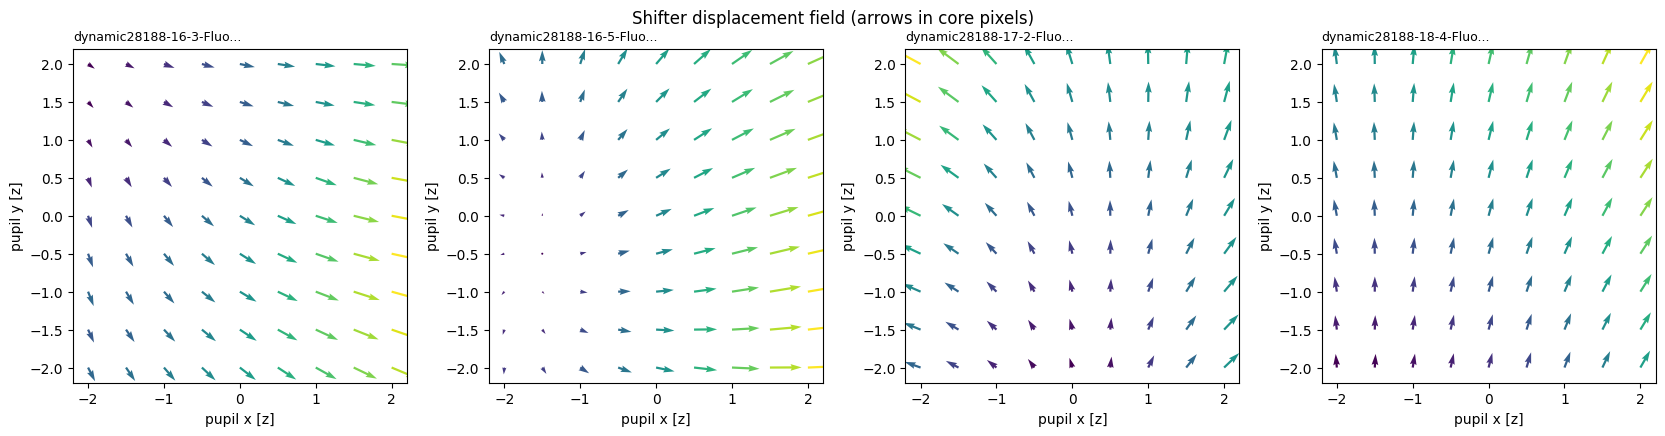

In [17]:
# Quiver of the shift field for a few sessions.
n_show = min(4, len(shifts))
fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4.2), squeeze=False)
step = 2  # thin the 17x17 grid so the arrows stay readable

for ax, (session, shift) in zip(axes[0], list(shifts.items())[:n_show]):
    pixels = shift_to_core_pixels(shift, core_output_shape, align_corners=align_corners[session])
    values = np.linspace(*BEHAVIOR_SWEEP_RANGE, shift.shape[0])
    mesh_x, mesh_y = np.meshgrid(values, values, indexing="ij")
    ax.quiver(
        mesh_x[::step, ::step], mesh_y[::step, ::step],
        pixels[::step, ::step, 0], pixels[::step, ::step, 1],
        np.linalg.norm(pixels[::step, ::step], axis=-1),
        cmap="viridis", angles="xy",
    )
    ax.set_xlabel("pupil x [z]")
    ax.set_ylabel("pupil y [z]")
    ax.set_title(session[:22] + "...", fontsize=9, loc="left")
    ax.set_aspect("equal")

fig.suptitle("Shifter displacement field (arrows in core pixels)")
plt.tight_layout()
plt.show()

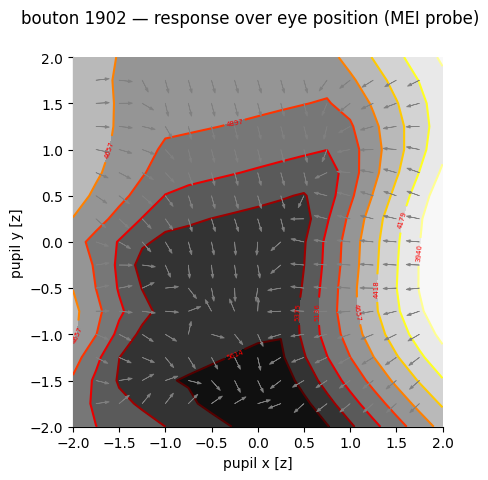

eye-position modulation index for the sampled boutons: [0.225 0.234 0.304 0.473 0.17  0.428 0.423 0.333 0.122 0.244 0.253 0.316
 0.115 0.345 0.235 0.979 0.239 0.136 0.191 0.448 0.214 0.263 0.311 0.389]


In [18]:
# What does that displacement cost in response terms? Loaded from grid_pupil_center.npz.
from openretina.utils.plotting import plot_vector_field_resp_iso

responses, gradients = pupil_grid.for_neuron(0)
figure = plot_vector_field_resp_iso(
    pupil_grid.axis_values[0],
    pupil_grid.axis_values[1],
    gradients,
    responses,
    xlabel=pupil_grid.axis_names[0],
    ylabel=pupil_grid.axis_names[1],
    tick_locations=None,
)
figure.suptitle(f"bouton {top_boutons[0]} — response over eye position (MEI probe)")
plt.show()

index = pupil_grid.modulation_index()
print("eye-position modulation index for the sampled boutons:", np.round(index, 3))

**Reading the eye-position sweep.** The shift is added *after* `mu` is clamped to `[-1, 1]`, so a
large enough shift pushes a bouton off the feature map and its response collapses. A plateau at the
edge of this grid is a property of the readout, not a tuning curve.

## Summary

- MEI amplitude changes with behavioral state while MEI structure stays nearly fixed — the gain-only
  prediction the architecture makes, now measured rather than assumed.
- The population modulation index quantifies how much of that gain there is, and the empirical
  density overlay marks which parts of the sweep the animal actually visited.
- The shifter's displacement, in core pixels, says whether eye-movement compensation is a
  few-pixel correction or something larger.